# Seismic Facies Classification using U-Net
**Author:** Venancio Ingersoll  
**Course:** GEO 352P  
**Date:** December 2025  

---

## 1. Motivation
Identifying salt bodies in seismic data is a critical but labor-intensive task in geophysical exploration. 
* **The Problem:** Salt bodies in the Gulf of Mexico have high velocity and complex shapes that obscure subsalt imaging. Accurately mapping them is useful for understanding how the bathymetry changed through time and can be useful  when drilling for natural resources or injecting CO2, as salt domes can trap fluids.

* **The Challenge:** Manual interpretation is time-consuming and subjective. A single 3D survey can contain thousands of lines, and is tedious to do by hand.

### Training Strategy
To address this, we trained a **U-Net** deep learning model. 
* **Data Curation:** The model did not train on full survey lines as that taked up too much memory. Instead, I generated a cache of **5,000 crop samples** (1024x256 pixels).
* **Balancing:** To prevent the model from biased learning (predicting "background" everywhere), we ensured these crops were balanced to have at least **40% salt presence**.
* **Normalization:** Applied robust normalization (clipping at 2.5 standard deviations) to handle the high-amplitude variability of seismic reflection data.


## 2. Dataset
The full dataset consists of approximately 12GB of SEG-Y data from the Gulf of Mexico.
* **Source:** [USGS NAMSS Survey B-07H-00-LA](https://walrus.wr.usgs.gov/namss/survey/b-07h-00-la/)
* **Labels:** The ground truth labels (salt masks) were manually interpreted and tagged in **Petrel** by me, for this project and other research.

Due to size constraints, this notebook demonstrates the model inference on a **local sample subset** consisting of 50 sequential inlines.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from src.inference_utils import load_segy_volume

# Define paths
SEISMIC_PATH = 'data/segy/sample_seismic.sgy'
MASK_PATH    = 'data/segy/sample_mask.sgy'

# Load the local sample volumes
print("--- Loading Seismic ---")
seismic_vol = load_segy_volume(SEISMIC_PATH)

print("\n--- Loading Ground Truth (Mask) ---")
mask_vol = load_segy_volume(MASK_PATH)

if seismic_vol is not None:
    print(f"\n✅ Data Loaded Successfully.")
    print(f"Volume Shape: {seismic_vol.shape} (Inlines, Depth, Traces)")

--- Loading Seismic ---
📖 Reading data/segy/sample_seismic.sgy...
   - Volume Size: 10 Inlines x 1601 Depth x 5289 Traces

--- Loading Ground Truth (Mask) ---
📖 Reading data/segy/sample_mask.sgy...
   - Volume Size: 10 Inlines x 1601 Depth x 5289 Traces

✅ Data Loaded Successfully.
Volume Shape: (10, 1601, 5289) (Inlines, Depth, Traces)


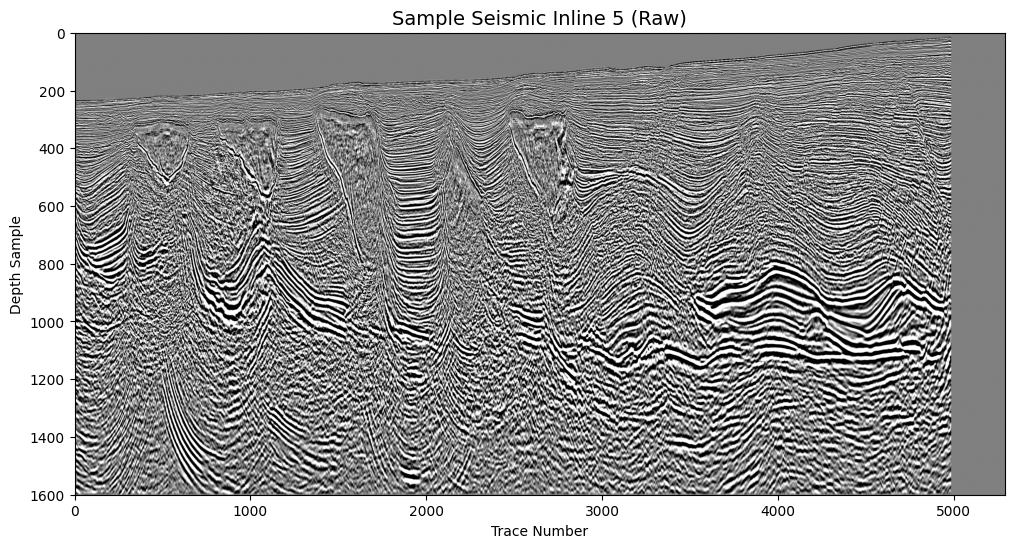

In [9]:
# Visualize the middle inline to verify data integrity
mid_idx = seismic_vol.shape[0] // 2

plt.figure(figsize=(12, 6))
plt.imshow(seismic_vol[mid_idx], cmap='gray', aspect='auto', vmin=-1.0, vmax=1.0)
plt.title(f"Sample Seismic Inline {mid_idx} (Raw)", fontsize=14)
plt.xlabel("Trace Number")
plt.ylabel("Depth Sample")
plt.show()

## 3. Methods
We utilized a standard **U-Net** architecture implemented in PyTorch. The U-Net is ideal for this segmentation task because it preserves spatial resolution via skip connections.

* **Libraries:** PyTorch, Segyio, NumPy, Matplotlib.
* **Architecture:** Encoder-Decoder with skip connections (4 levels deep).
* **Loss Function:** CrossEntropyLoss.
* **Optimizer:** Adam (Learning Rate: 1e-4).

In [1]:
import torch
from src.inference_utils import SeismicHunter, create_prediction_plot

# Initialize the "SeismicHunter" (Helper class for inference)
MODEL_PATH = 'models/best_model.pth'

# Check if model exists
try:
    hunter = SeismicHunter(MODEL_PATH)
except FileNotFoundError:
    print(f"❌ Error: Model file not found at {MODEL_PATH}")
    print("Please ensure 'best_model.pth' is inside the 'models/' folder.")

   🚀 Loading Model on cuda...


RuntimeError: Error(s) in loading state_dict for UNet:
	Missing key(s) in state_dict: "inc.0.weight", "inc.0.bias", "inc.1.weight", "inc.1.bias", "inc.1.running_mean", "inc.1.running_var", "inc.3.weight", "inc.3.bias", "inc.4.weight", "inc.4.bias", "inc.4.running_mean", "inc.4.running_var", "conv1.0.weight", "conv1.0.bias", "conv1.1.weight", "conv1.1.bias", "conv1.1.running_mean", "conv1.1.running_var", "conv1.3.weight", "conv1.3.bias", "conv1.4.weight", "conv1.4.bias", "conv1.4.running_mean", "conv1.4.running_var", "conv2.0.weight", "conv2.0.bias", "conv2.1.weight", "conv2.1.bias", "conv2.1.running_mean", "conv2.1.running_var", "conv2.3.weight", "conv2.3.bias", "conv2.4.weight", "conv2.4.bias", "conv2.4.running_mean", "conv2.4.running_var", "conv3.0.weight", "conv3.0.bias", "conv3.1.weight", "conv3.1.bias", "conv3.1.running_mean", "conv3.1.running_var", "conv3.3.weight", "conv3.3.bias", "conv3.4.weight", "conv3.4.bias", "conv3.4.running_mean", "conv3.4.running_var", "conv4.0.weight", 

## 4. Results & Interactive Demonstration
Below, we run the model on the sample volume loaded above. 
The code iterates through the volume, generates predictions, and compiles them into an animated GIF to visualize the 3D structure of the salt body compared to the ground truth.

In [ ]:
from PIL import Image
import os

# Create directory for frames if it doesn't exist
if not os.path.exists('output/temp'):
    os.makedirs('output/temp')
if not os.path.exists('output/gifs'): 
    os.makedirs('output/gifs')

frames = []
print("🎥 Generating animation frames...")

# Iterate through the inlines in our sample volume
for i in range(seismic_vol.shape[0]):
    # 1. Get Slice (NO TRANSPOSE NEEDED)
    seismic_slice = seismic_vol[i]     # <--- Changed
    mask_slice = mask_vol[i] if mask_vol is not None else None # <--- Changed
    
    # 2. Run Inference
    prob_map = hunter.predict_slice(seismic_slice)
    
    # 3. Create Plot (Helper function handles overlay)
    fig = create_prediction_plot(seismic_slice, prob_map, mask=mask_slice, figsize=(10, 8))
    
    # 4. Save Frame
    filename = f"output/temp/frame_{i}.png"
    plt.savefig(filename)
    plt.close()
    
    # 5. Append to GIF list
    frames.append(Image.open(filename))
    print(f"   Processed frame {i+1}/{seismic_vol.shape[0]}", end='\r')

# Save the GIF
gif_path = 'output/gifs/salt_prediction.gif'

if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        optimize=True,
        duration=500, 
        loop=0
    )
    print(f"\n✅ GIF Saved: {gif_path}")
else:
    print("\n❌ No frames generated.")

### Visualized Result
Below is the animation generated from the code above. 
* **Top:** Seismic input with the manual ground truth (Gold).
* **Bottom:** Seismic input with the model's probability prediction (Jet/Rainbow).

![Salt Prediction](../output/gifs/salt_prediction.gif)

## 5. Conclusions
* **Performance:** The model showed a significant improvement over standard auto-tracking on the tagged dataset. It successfully identified complex, chaotic salt boundaries that traditional amplitude-thresholding methods often miss.
* **The "Discovery":** Interestingly, the model identified potential salt structures deep in the section that were **missed during the manual tagging phase**, suggesting the model learned the textural signature of salt effectively.

### Future Work
* **Generalization:** When applied to a completely different survey (different frequency content and acquisition parameters), the model's performance dropped. Future work involves applying **Transfer Learning** or using Domain Adaptation techniques to make the model robust across different surveys.
* **Architecture:** Exploring Transformer-based architectures (e.g., SegFormer) to capture larger global context.

---
